# 1D Heat Equation: Explicit vs Crank-Nicolson Comparison

This notebook compares two time-stepping methods for solving the 1D heat equation:
- **Explicit FTCS** (Forward Time Central Space) - conditionally stable
- **Crank-Nicolson** - unconditionally stable

Both use Neumann boundary conditions (insulated ends).

In [1]:
import time
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Parameters

We use `nx=100` as the default grid size (crossover point where explicit beats CN on CPU).
The time step `dt` is auto-calculated from the CFL stability condition: $r = \frac{\alpha \Delta t}{\Delta x^2} \leq 0.5$

In [2]:
# Physical parameters
L = 1.0           # Domain length [m]
alpha = 0.00025      # Thermal diffusivity [m^2/s]
T_total = 5.0     # Total simulation time [s]

# Grid size (crossover point where explicit beats CN on CPU)
nx = 1000

# Auto-calculate dt from stability condition
dx = L / (nx - 1)
r_target = 0.45    # Safety margin below 0.5
dt = r_target * dx**2 / alpha
nt = int(T_total / dt) + 1

# Stability parameters
r_explicit = alpha * dt / dx**2
r_cn = alpha * dt / (2 * dx**2)

print(f"Grid: {nx} points, {nt} time steps")
print(f"dx = {dx:.6f}, dt = {dt:.6f}")
print(f"r_explicit = {r_explicit:.4f} (stable: {r_explicit <= 0.5})")
print(f"r_cn = {r_cn:.4f}")

Grid: 1000 points, 2773 time steps
dx = 0.001001, dt = 0.001804
r_explicit = 0.4500 (stable: True)
r_cn = 0.2250


## Solver Functions

In [3]:
def build_crank_nicolson_matrices(nx, r, device=None):
    """Build A and B matrices for Crank-Nicolson scheme with Neumann BCs."""
    if device is None:
        device = torch.device('cpu')

    A = torch.zeros((nx, nx), device=device)
    B = torch.zeros((nx, nx), device=device)

    for i in range(1, nx - 1):
        A[i, i-1], A[i, i], A[i, i+1] = -r, 1 + 2*r, -r
        B[i, i-1], B[i, i], B[i, i+1] = r, 1 - 2*r, r

    # Neumann BCs
    A[0, 0], A[0, 1] = 1 + 2*r, -2*r
    B[0, 0], B[0, 1] = 1 - 2*r, 2*r
    A[nx-1, nx-2], A[nx-1, nx-1] = -2*r, 1 + 2*r
    B[nx-1, nx-2], B[nx-1, nx-1] = 2*r, 1 - 2*r

    return A, B


def build_explicit_matrix(nx, r, device=None):
    """Build matrix D for explicit scheme: u^{n+1} = D @ u^n"""
    if device is None:
        device = torch.device('cpu')

    D = torch.zeros((nx, nx), device=device)

    for i in range(1, nx - 1):
        D[i, i-1] = r
        D[i, i] = 1 - 2*r
        D[i, i+1] = r

    # Neumann BCs
    D[0, 0] = 1 - 2*r
    D[0, 1] = 2*r
    D[nx-1, nx-2] = 2*r
    D[nx-1, nx-1] = 1 - 2*r

    return D


def solve_crank_nicolson(A, B, u0, nt, save_every=1):
    """Solve heat equation using Crank-Nicolson method."""
    nx = u0.shape[0]
    n_saved = nt // save_every + 1
    u_history = torch.zeros((n_saved, nx), device=u0.device, dtype=u0.dtype)
    u_history[0] = u0.clone()

    u = u0.clone()
    save_idx = 1

    for n in range(1, nt + 1):
        u = torch.linalg.solve(A, B @ u)
        if n % save_every == 0:
            u_history[save_idx] = u.clone()
            save_idx += 1

    return u_history


def solve_explicit(D, u0, nt, save_every=1):
    """Solve heat equation using explicit FTCS (matmul)."""
    nx = u0.shape[0]
    n_saved = nt // save_every + 1
    u_history = torch.zeros((n_saved, nx), device=u0.device, dtype=u0.dtype)
    u_history[0] = u0.clone()

    u = u0.clone()
    save_idx = 1

    for n in range(1, nt + 1):
        u = D @ u
        if n % save_every == 0:
            u_history[save_idx] = u.clone()
            save_idx += 1

    return u_history


def initial_condition(x, kind='gaussian'):
    """Generate initial temperature distribution."""
    L = x[-1] - x[0]
    x0 = (x[0] + x[-1]) / 2
    if kind == 'gaussian':
        sigma = L / 10
        return torch.exp(-((x - x0) ** 2) / (2 * sigma ** 2))
    elif kind == 'step':
        return torch.where((x > 0.3 * L) & (x < 0.7 * L),
                          torch.ones_like(x), torch.zeros_like(x))
    elif kind == 'sine':
        return torch.sin(torch.pi * x / L)
    raise ValueError(f"Unknown kind: {kind}")


print("Solver functions defined.")

Solver functions defined.


## Run Solvers and Benchmark

In [4]:
def benchmark_solver(solver_fn, *args, n_runs=5, warmup=1, use_cuda=False):
    """Benchmark a solver function."""
    for _ in range(warmup):
        _ = solver_fn(*args)
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        if use_cuda:
            torch.cuda.synchronize()
        start = time.perf_counter()
        result = solver_fn(*args)
        if use_cuda:
            torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
    return result, times


# Determine devices
has_cuda = torch.cuda.is_available()
devices = [torch.device('cpu')]
if has_cuda:
    devices.append(torch.device('cuda'))

save_every = max(1, nt // 100)
results = {}

for device in devices:
    device_name = 'GPU' if device.type == 'cuda' else 'CPU'
    print(f'Running on {device_name}...')

    x = torch.linspace(0, L, nx, device=device)
    u0 = initial_condition(x, kind='gaussian')
    A, B = build_crank_nicolson_matrices(nx, r_cn, device)
    D = build_explicit_matrix(nx, r_explicit, device)

    use_cuda = device.type == 'cuda'

    if use_cuda:
        _ = solve_crank_nicolson(A, B, u0, 10)
        _ = solve_explicit(D, u0, 10)
        torch.cuda.synchronize()

    print('  Crank-Nicolson...')
    u_cn, times_cn = benchmark_solver(
        solve_crank_nicolson, A, B, u0, nt, save_every,
        n_runs=1, warmup=1, use_cuda=use_cuda
    )

    print('  Explicit FTCS...')
    u_exp, times_exp = benchmark_solver(
        solve_explicit, D, u0, nt, save_every,
        n_runs=1, warmup=1, use_cuda=use_cuda
    )

    results[device_name] = {
        'cn_times': times_cn,
        'exp_times': times_exp,
        'u_cn': u_cn.cpu(),
        'u_exp': u_exp.cpu(),
        'x': x.cpu(),
    }

print('Done!')


Running on CPU...
  Crank-Nicolson...
  Explicit FTCS...
Running on GPU...
  Crank-Nicolson...
  Explicit FTCS...
Done!


## Temperature Evolution Plots

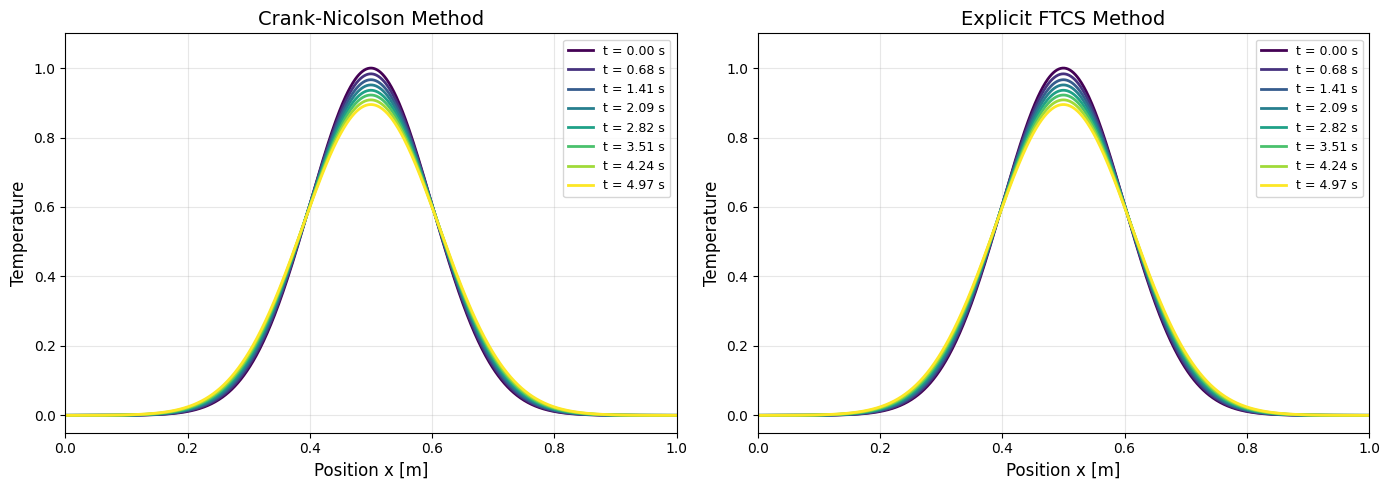

Saved: comparison_evolution.png


In [5]:

# Prepare data
x_np = results['CPU']['x'].numpy()
u_cn_np = results['CPU']['u_cn'].numpy()
u_exp_np = results['CPU']['u_exp'].numpy()
t_array = [i * dt * save_every for i in range(nt // save_every + 1)]

# Plot settings
n_snapshots = 8
indices = [int(i * (len(t_array) - 1) / (n_snapshots - 1)) for i in range(n_snapshots)]
colors = plt.cm.viridis([i / (n_snapshots - 1) for i in range(n_snapshots)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crank-Nicolson
ax = axes[0]
for idx, color in zip(indices, colors):
    ax.plot(x_np, u_cn_np[idx], color=color, linewidth=2, label=f't = {t_array[idx]:.2f} s')
ax.set_xlabel('Position x [m]', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title('Crank-Nicolson Method', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, L])
ax.set_ylim([-0.05, 1.1])

# Explicit FTCS
ax = axes[1]
for idx, color in zip(indices, colors):
    ax.plot(x_np, u_exp_np[idx], color=color, linewidth=2, label=f't = {t_array[idx]:.2f} s')
ax.set_xlabel('Position x [m]', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title('Explicit FTCS Method', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, L])
ax.set_ylim([-0.05, 1.1])

plt.tight_layout()
plt.savefig('comparison_evolution.png', dpi=150)
plt.show()
print("Saved: comparison_evolution.png")

## Benchmark Summary

In [6]:
print('=' * 65)
print('BENCHMARK SUMMARY')
print('=' * 65)
print(f'Grid: {nx} points, {nt} time steps')
print(f'r_explicit = {r_explicit:.4f}, r_cn = {r_cn:.4f}')
print('-' * 65)
print(f"{'Method':<25} {'Device':<10} {'Time [ms]':<15} {'Speedup vs CPU'}")
print('-' * 65)

methods = [
    ('Crank-Nicolson', 'cn_times'),
    ('Explicit FTCS',  'exp_times'),
]

for method, key in methods:
    cpu_ms = sum(results['CPU'][key]) / len(results['CPU'][key]) * 1000
    print(f"{method:<25} {'CPU':<10} {cpu_ms:<15.2f} {'(baseline)'}")

    if has_cuda:
        gpu_ms  = sum(results['GPU'][key]) / len(results['GPU'][key]) * 1000
        speedup = cpu_ms / gpu_ms
        print(f"{'':<25} {'GPU':<10} {gpu_ms:<15.2f} {speedup:.2f}x")

print('=' * 65)


BENCHMARK SUMMARY
Grid: 1000 points, 2773 time steps
r_explicit = 0.4500, r_cn = 0.2250
-----------------------------------------------------------------
Method                    Device     Time [ms]       Speedup vs CPU
-----------------------------------------------------------------
Crank-Nicolson            CPU        56151.66        (baseline)
                          GPU        27406.45        2.05x
Explicit FTCS             CPU        1032.65         (baseline)
                          GPU        106.11          9.73x
